In [29]:
import numpy as np

from engioptiqa import AnnealingSolverAmplify, TrussStructure, TrussStructureOptimization

In [30]:
ts = TrussStructure()

In [31]:
ts.add_node(0, (0,0))  # Node 0 at (0,0)
ts.add_node(1, (1,0))  # Node 1 at (1,0)
ts.add_node(2, (0,1))  # Node 2 at (0,1)

In [32]:
ts.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
ts.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2

In [33]:
ts.get_member_info()

[{'Member': 0,
  'Node 0': 0,
  'Node 1': 1,
  'Length': 1.0,
  'Direction Cosines (Node 0)': (1.0, 0.0),
  'Direction Cosines (Node 1)': (-1.0, 0.0),
  'Area (A)': 0.5,
  "Young's Modulus (E)": 200000000000.0},
 {'Member': 1,
  'Node 0': 1,
  'Node 1': 2,
  'Length': 1.4142135623730951,
  'Direction Cosines (Node 0)': (-0.7071067811865475, 0.7071067811865475),
  'Direction Cosines (Node 1)': (0.7071067811865475, -0.7071067811865475),
  'Area (A)': 0.5,
  "Young's Modulus (E)": 200000000000.0}]

In [34]:
ts.get_node_info()

{0: (0, 0), 1: (1, 0), 2: (0, 1)}

In [35]:
ts.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

In [36]:
ts.get_load_info()

{1: (0, -100000.0)}

In [37]:
ts.add_support(0, True, True)  # Fixed support at Node 0
ts.add_support(2, True, True)  # Fixed support at Node 2

In [38]:
# Get node information
print("Nodes:")
print(ts.get_node_info())

# Get member information
print("\nMembers:")
for member in ts.get_member_info():
    print(member)

# Get load information
print("\nLoads:")
print(ts.get_load_info())

# Get support information
print("\nSupports:")
print(ts.get_support_info())

Nodes:
{0: (0, 0), 1: (1, 0), 2: (0, 1)}

Members:


{'Member': 0, 'Node 0': 0, 'Node 1': 1, 'Length': 1.0, 'Direction Cosines (Node 0)': (1.0, 0.0), 'Direction Cosines (Node 1)': (-1.0, 0.0), 'Area (A)': 0.5, "Young's Modulus (E)": 200000000000.0}
{'Member': 1, 'Node 0': 1, 'Node 1': 2, 'Length': 1.4142135623730951, 'Direction Cosines (Node 0)': (-0.7071067811865475, 0.7071067811865475), 'Direction Cosines (Node 1)': (0.7071067811865475, -0.7071067811865475), 'Area (A)': 0.5, "Young's Modulus (E)": 200000000000.0}

Loads:
{1: (0, -100000.0)}

Supports:
{0: (True, True), 2: (True, True)}


Max Area: 0.5


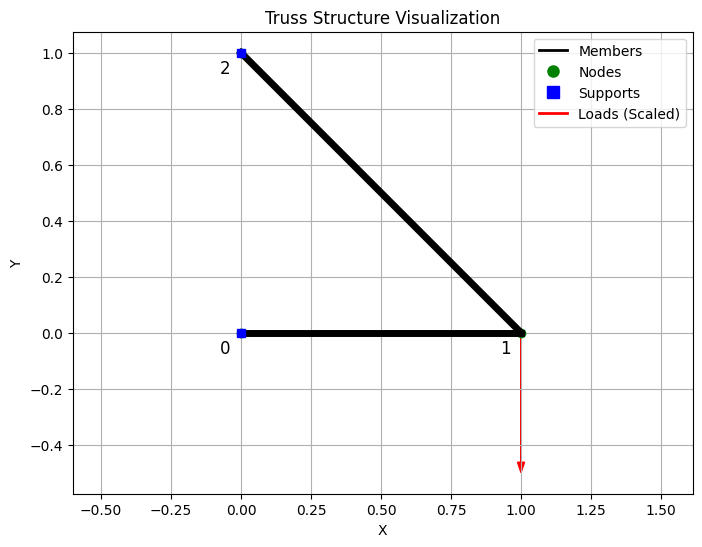

In [39]:
ts.visualize()

In [40]:
member_forces, compliance = ts.compute_member_forces()
print("Member Forces:")
for i_member, force in member_forces.items():
    print(f"\tF_{i_member} = {force} ")

Compliance: 0.38284271247461915
Member Forces:
	F_0 = -100000.00000000004 
	F_1 = 141421.35623730952 


In [41]:
ts.generate_discretization(n_qubits_per_member=3,
                           binary_representation='range',
                           lower_lim=-2e5, upper_lim=3e5)
ts.generate_objective(penalty_weight_joints=1e3)

Node 0
Node 1
	Residual force in x-direction: - 35714.2857142857 q_0 - 71428.5714285714 q_1 - 142857.142857143 q_2 - 25253.8136138053 q'_0 - 50507.6272276105 q'_1 - 101015.254455221 q'_2 + 170710.67811865476
	Residual force in y-direction:  25253.8136138053 q'_0 + 50507.6272276105 q'_1 + 101015.254455221 q'_2 - 170710.67811865476
Node 2


In [42]:
token_dict = {'fixstars': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Fixstars.txt'}
proxy='http://proxy.ilsb.tuwien.ac.at:3128'
annealing_solver_gpu = AnnealingSolverAmplify(client_type='fixstars', token_file=token_dict['fixstars'], proxy=proxy)
annealing_solver_gpu.setup_solver()

Setting default timeout (ms): 800
Created solver


In [43]:
annealing_solver_gpu.solve_problem(ts)

Number of solutions: 1


In [44]:
best_solution, solutions = ts.analyze_results()

Node 0
Node 1
	Residual force in x-direction: -6066.017177982139
	Residual force in y-direction:  6066.017177982139
Node 2
Best solution (minimum objective):
Objective: 73593128807.35791
Complementary Energy: 0.20909902576697326
Volume: 1.2071067811865475
Joint Residuals (squared): 73593128.8071488
Member Forces: [-100000.0, 150000.00000000003]
Member Stresses: [-200000.0, 300000.00000000006]
Member Areas: [0.5, 0.5]


In [45]:
rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
print('Compliance:')
print('===========')
print(f'  Reference: {compliance:.8e}')
print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
print(f'  Rel. Diff: {rel_error_compliance:.2e}')
print('Force:')
print('======')
for i_member, member in enumerate(ts.members):
    rel_error_force = abs((member_forces[i_member]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member])
    print(f'  Member {i_member}:')
    print(f'    Reference: {member_forces[i_member]:.8e}')
    print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
    print(f'    Rel. Diff: {rel_error_force:.2e}')

Compliance:
  Reference: 3.82842712e-01
  Solution 4.18198052e-01
  Rel. Diff: 9.23e-02
Force:
  Member 0:
    Reference: -1.00000000e+05
    Solution -1.00000000e+05
    Rel. Diff: 4.37e-16
  Member 1:
    Reference: 1.41421356e+05
    Solution 1.50000000e+05
    Rel. Diff: 6.07e-02


In [46]:
def set_real_number_range(problem, iteration, member_stresses_sol_hist, best_sample, min_range):
    print(" Adjust real number representations. ".center(80, '-'))
    n_qubits_per_member = problem.n_qubits_per_member
    n_members = problem.n_members
    n_qubits = n_qubits_per_member * n_members

    a = member_stresses_sol_hist[iteration]
    a_prev = member_stresses_sol_hist[iteration-1]
    a_min = problem.a_min
    a_max = problem.a_max

    # Convert SampleSet to bit array with correct bitmapping
    bit_dict = best_sample
    # print(f'Bit dict: {bit_dict}\n')
    ordered_keys = list(range(n_qubits))
    # bit_array = [bit_dict[k] for k in ordered_keys]
    # print(f"Bit array: {bit_array}\n")
    bit_array = [int(best_sample[k]) for k in best_sample]

    c = 0.8
    for i_member in range(n_members):
        print(f"Member {i_member}:")
        start = i_member * n_qubits_per_member
        end = (i_member + 1) * n_qubits_per_member
        qubits = bit_array[start:end]
        # delta = max(a_max[node] - a_min[node], min_range)
        delta = a_max[i_member] - a_min[i_member]
        print(f"\tCurrent range: [{a_min[i_member]}, {a_max[i_member]}], ({delta})")
        print(f"\t{a_prev[i_member]} -> {a[i_member]}")

        # Save old range
        old_min = a_min[i_member]
        old_max = a_max[i_member]

        # Restrict the range of a_min and a_max based on the previous iteration
        if delta > min_range:
            if a[i_member] < a_prev[i_member]:
                # a_max[node] = a_prev[node]
                a_max[i_member] = a_max[i_member] + c*(a_prev[i_member] - a_max[i_member]) # Relaxed version
                print("\tLowering upper bound.")
            elif a[i_member] > a_prev[i_member]:
                # a_min[node] = a_prev[node]
                a_min[i_member] = a_min[i_member] + c*(a_prev[i_member] - a_min[i_member]) # Relaxed version
                print("\tRaising lower bound.")
            elif a[i_member] == a_prev[i_member]:
                # a_min[node] = a_min[node] + delta * c
                # a_max[node] = a_max[node] - delta * c
                a_min[i_member] = a_min[i_member] - (a_min[i_member]-a[i_member]) * c
                a_max[i_member] = a_max[i_member] - (a_max[i_member]-a[i_member]) * c
                print("\tShrinking range.")


        # Expand range if all qubits at a node are 1 or 0
        if all(q == 1 for q in qubits):
            print(f"\tAll qubits are 1, expanding range in positive direction.")
            a_max[i_member] += 0.05 * delta
        elif all(q == 0 for q in qubits):
            print(f"\tAll qubits are 0, expanding range in negative direction.")
            a_min[i_member] -= 0.05 * delta

        # Enforce minimum range
        if a_max[i_member] - a_min[i_member] < min_range:
            print(f"\tRange too small, enforcing minimum range of {min_range}.")
            mid = 0.5 * (a_max[i_member] + a_min[i_member])
            a_min[i_member] = mid - 0.5 * min_range
            a_max[i_member] = mid + 0.5 * min_range

        if old_min != a_min[i_member] or old_max != a_max[i_member]:
            print(f"\tUpdated range: [{a_min[i_member]}, {a_max[i_member]}], ({a_max[i_member] - a_min[i_member]})")

    print("Updated a_min and a_max for all nodes:")
    print("a_min:", problem.a_min)
    print("a_max:", problem.a_max)


In [47]:
penalty_weight = 1e1
m_lambda = 2
min_range = 1e-5
tol_member_stresses = 1e-6
max_iteration = 20
histories = {
    'objective': [best_solution['objective']],
    'compl_energy': [best_solution['complementary_energy']],
    'member_stresses': [best_solution['member_stresses']],
    'member_stresses_rel_change': [],
    # 'error_h1_rel': [error_h1_rel],
    # 'constraint': [constraint],
    'penalty_weight': [penalty_weight],
    # 'penalty_term': [penalty_weight * constraint],
}


histories['number_representation_range'] = {
    'a_min': [ts.a_min.copy()],
    'a_max': [ts.a_max.copy()],
}

iteration = 0
# Itetarively solve the problem while increasing the penalty weight
while iteration < max_iteration:
    iteration += 1
    print(f' Iteration {iteration} '.center(80, '='))

    # Set penalty weight depending on previous constraint violation
    print(" Update the penalty weight. ".center(80, '-'))
    penalty_weight *= m_lambda
    penalty_weight = min(penalty_weight, 1e12)
    ts.update_penalty_weight_in_objective(penalty_weight_joints=penalty_weight)
    # self.histories['penalty_weight'].append(penalty_weight)

    # Real number representation range update
    if iteration > 1 and ts.binary_representation == 'range':
        set_real_number_range(ts, iteration - 1, histories['member_stresses'], ts.results[0].values, min_range)

    print(" Update QUBO formulation. ".center(80, '-'))
    # Update nodal force polys
    ts.update_member_stress_polys()
    # Regeneate QUBO formulation
    ts.generate_objective(penalty_weight_joints=penalty_weight)

    # Check if all qubits are still present in the problem
    # n_bits_current = ts.binary_quadratic_model.num_logical_vars
    # if n_bits_current != n_bits:
    #     print(f"Missing qubits. Exiting.")
    #     break


    # Solve problem
    annealing_solver_gpu.solve_problem(ts)

    best_solution, solutions = ts.analyze_results()

    histories['objective'].append(best_solution['objective'])
    # Complementary energy
    histories['compl_energy'].append(best_solution['complementary_energy'])
    # Member stresses
    member_stresses_prev = histories['member_stresses'][-1]
    histories['member_stresses'].append(best_solution['member_stresses'])
    member_stresses_magnitude = np.linalg.norm(np.array(best_solution['member_stresses']), axis=0)
    member_stresses_rel_change = np.linalg.norm(
        np.array(best_solution['member_stresses']) - np.array(member_stresses_prev),
        axis=0
    ) / member_stresses_magnitude
    histories['member_stresses_rel_change'].append(member_stresses_rel_change)
    print(f"Relative change in nodal forces: {member_stresses_rel_change:.6e}")
    histories['number_representation_range']['a_min'].append(ts.a_min.copy())
    histories['number_representation_range']['a_max'].append(ts.a_max.copy())

    # Joint residuals
    # self.histories['constraint'].append(constraint)
    # print(f"Current constraint violation: {constraint:.6e}")
    # Penalty term (penalty_weight * constraint)
    # self.histories['penalty_term'].append(self.problem.penalty_weight_equilibrium * constraint)


    # Store the best sample as initial state for the next iteration
    # best_sample = self.get_best_sample_as_dict()

    # print(" Analyze solution. ".center(80, '-'))
    # nf, nf_rel_change = self.analyze_and_store_solution()

    # Terminate if relative change in nodal forces is below tolerance or maximum iterations reached
    if iteration > 1 and member_stresses_rel_change < tol_member_stresses:
        print(f"Convergence reached with relative change in nodal forces ({member_stresses_rel_change:.6e} < {tol_member_stresses:.3e}).")
        break
    if iteration == max_iteration:
        print(f"Reached maximum iterations ({max_iteration}).")

print(f" Finished after {iteration} iterations. ".center(80, '#'))


================================= Iteration 1 ==================================
-------------------------- Update the penalty weight. --------------------------
Penalty weight (joints): 20.0

--------------------------- Update QUBO formulation. ---------------------------
Node 0
Node 1
	Residual force in x-direction: - 35714.2857142857 q_0 - 71428.5714285714 q_1 - 142857.142857143 q_2 - 25253.8136138053 q'_0 - 50507.6272276105 q'_1 - 101015.254455221 q'_2 + 170710.67811865476
	Residual force in y-direction:  25253.8136138053 q'_0 + 50507.6272276105 q'_1 + 101015.254455221 q'_2 - 170710.67811865476
Node 2
Number of solutions: 1
Node 0
Node 1
	Residual force in x-direction: -6066.017177982139
	Residual force in y-direction:  6066.017177982139
Node 2
Best solution (minimum objective):
Objective: 1471862576.352075
Complementary Energy: 0.20909902576697326
Volume: 1.2071067811865475
Joint Residuals (squared): 73593128.8071488
Member Forces: [-100000.0, 150000.00000000003]
Member Stresses: 

In [48]:
rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
print('Compliance:')
print('===========')
print(f'  Reference: {compliance:.8e}')
print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
print(f'  Rel. Diff: {rel_error_compliance:.2e}')
print('Force:')
print('======')
for i_member, member in enumerate(ts.members):
    rel_error_force = abs((member_forces[i_member]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member])
    print(f'  Member {i_member}:')
    print(f'    Reference: {member_forces[i_member]:.8e}')
    print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
    print(f'    Rel. Diff: {rel_error_force:.2e}')

Compliance:
  Reference: 3.82842712e-01
  Solution 3.82841602e-01
  Rel. Diff: 2.90e-06
Force:
  Member 0:
    Reference: -1.00000000e+05
    Solution -9.99998474e+04
    Rel. Diff: 1.53e-06
  Member 1:
    Reference: 1.41421356e+05
    Solution 1.41421155e+05
    Rel. Diff: 1.42e-06
